# Data Project

## 1.1

Starting of by getting the data using the dstapi, and showing the data using tablesummary to get an idea of the variables and values the data contains.

In [79]:
# Import packages
import numpy as np
import pandas as pd
from dstapi import DstApi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [80]:
%reload_ext autoreload
%autoreload 2

In [81]:

# Get data from API and check what's in it
data = DstApi('PRIS113')
data.tablesummary(language='en')

Table PRIS113: Consumer price index by type and time
Last update: 2026-01-12T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,TYPE,1,INDEKS,Consumer price index,INDEKS,Consumer price index,False
1,Tid,552,1980M01,1980M01,2025M12,2025M12,True


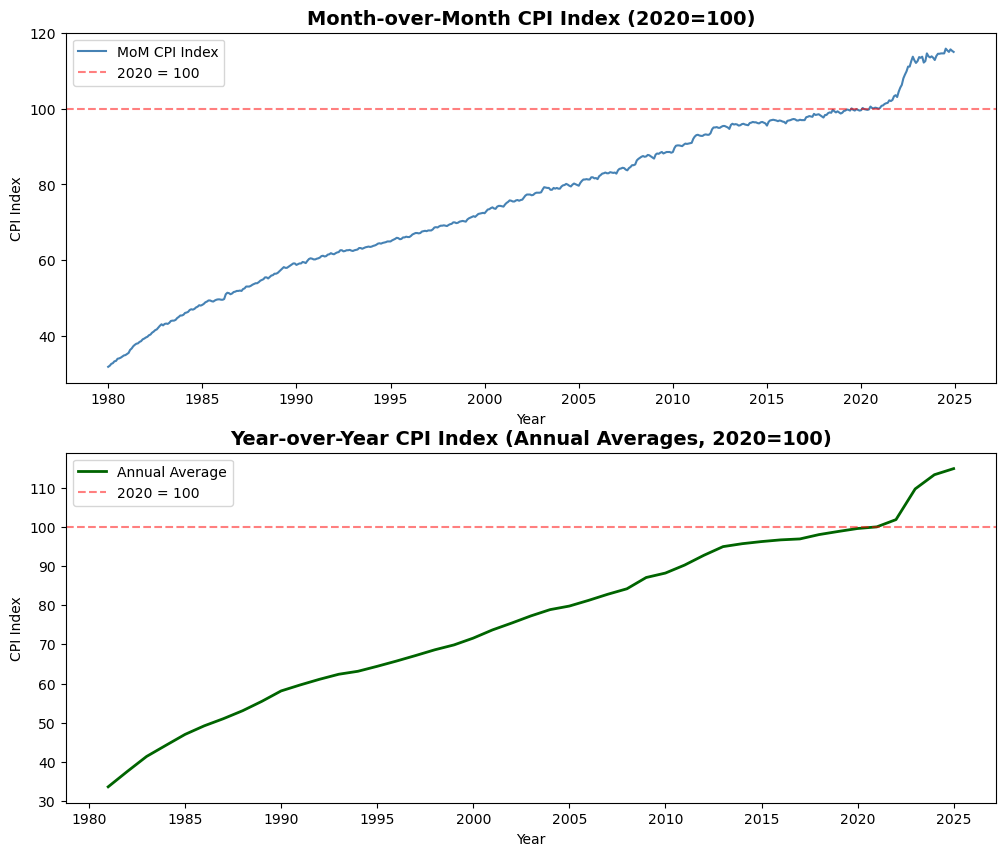

In [82]:
# Pull index data from API
params = data._define_base_params(language='en')
for var in params['variables']:
    if var['code'] == 'TYPE':
        var['values'] = ['INDEKS']

df = data.get_data(params=params)

# Convert date and values to proper format
df['TID'] = pd.to_datetime(df['TID'], format='%YM%m')
df['INDHOLD'] = pd.to_numeric(df['INDHOLD'], errors='coerce')
df = df.dropna(subset=['TID', 'INDHOLD']).sort_values('TID').reset_index(drop=True)

# Keep data from 1980-2024 (last full year available)
df = df[(df['TID'] >= '1980-01-01') & (df['TID'] <= '2024-12-31')].copy().reset_index(drop=True)
    
# Index 2020=100
ref_2020 = df[df['TID'].dt.year == 2020]['INDHOLD'].mean()
df['index_2020_100'] = (df['INDHOLD'] / ref_2020) * 100

# Calculate month-over-month growth
df['mom_growth'] = df['INDHOLD'].pct_change(fill_method=None)

# Find 2020 starting point
if not df[df['TID'] == '2020-01-01'].empty:
    idx_2020_start = df[df['TID'] == '2020-01-01'].index[0]
else:
    print("Warning: 2020-01-01 not found. Using first date.")
    idx_2020_start = df.index[0]

# Build index using pct_change method
df['index_pct_method'] = np.nan
df.loc[idx_2020_start, 'index_pct_method'] = 100.0

for i in range(idx_2020_start + 1, len(df)):
    df.loc[i, 'index_pct_method'] = df.loc[i-1, 'index_pct_method'] * (1 + df.loc[i, 'mom_growth'])
for i in range(idx_2020_start - 1, -1, -1):
    df.loc[i, 'index_pct_method'] = df.loc[i+1, 'index_pct_method'] / (1 + df.loc[i+1, 'mom_growth'])

# Plot both methods
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# MoM CPI index
axes[0].plot(df['TID'], df['index_2020_100'], linewidth=1.5, color='steelblue', label='MoM CPI Index')
axes[0].axhline(y=100, color='red', linestyle='--', alpha=0.5, label='2020 = 100')
axes[0].set_title('Month-over-Month CPI Index (2020=100)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CPI Index')
axes[0].legend()

# YoY annual averages
df_annual = df.set_index('TID')['index_2020_100'].resample('YE').mean().to_frame()
df_annual['year'] = df_annual.index.year
axes[1].plot(df_annual.index, df_annual['index_2020_100'], linewidth=2, color='darkgreen', label='Annual Average')
axes[1].axhline(y=100, color='red', linestyle='--', alpha=0.5, label='2020 = 100')
axes[1].set_title('Year-over-Year CPI Index (Annual Averages, 2020=100)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('CPI Index')
axes[1].legend()

plt.show()

From this data its clear to the Corona inflation ended around 2022, when its clear to see the CPI slowed its growth

## 1.2

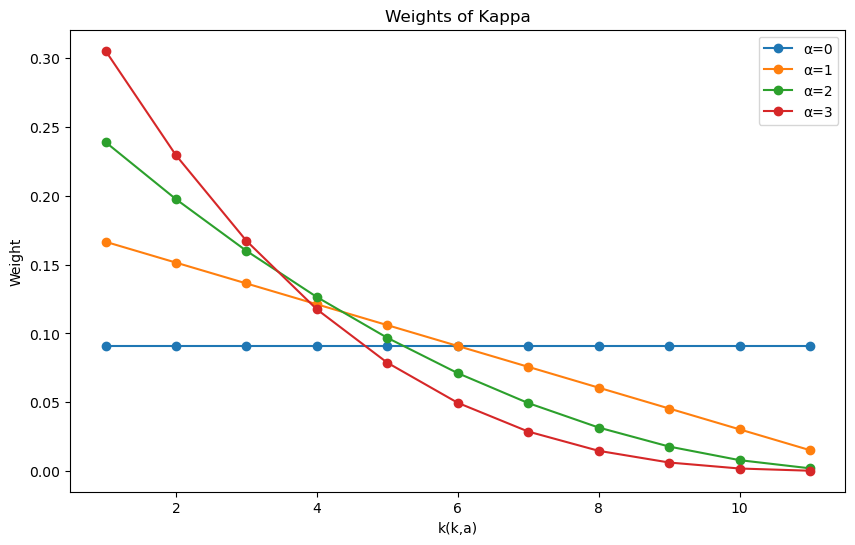

In [83]:
# Set up variables
t = 12 
alpha = [0, 1, 2, 3]
ks = list(range(1, 12))

# Define kappa weights function
def kappa_weights(t, alpha):
    ks_arr = np.array(ks, dtype=float)
    raw = (t - ks_arr) ** alpha
    # Avoid division by zero
    total = raw.sum()
    if total == 0:
        return np.zeros_like(raw)
    return raw / total
# Plot kappa weights for different alphas

fig, ax = plt.subplots(figsize=(10, 6))
for a in alpha:
    ax.plot(ks, kappa_weights(t, a), marker='o', label=f'α={a}')
ax.set_title("Weights of Kappa")
ax.set_xlabel("k(k,a)")
ax.set_ylabel("Weight")
ax.legend()

plt.show()

If a = 0 all the inflation is spread equally among all the periods
If a = 1 there is a slightly higher weight in recent months.
If a = 2 the inflation is more sensitive in the recent months.
If a = 3 the inflation is highly sensitive in the recent months
higher alpha leads to more weight being put on the recent months, meaning that inflation is more dependendt on new price developments 

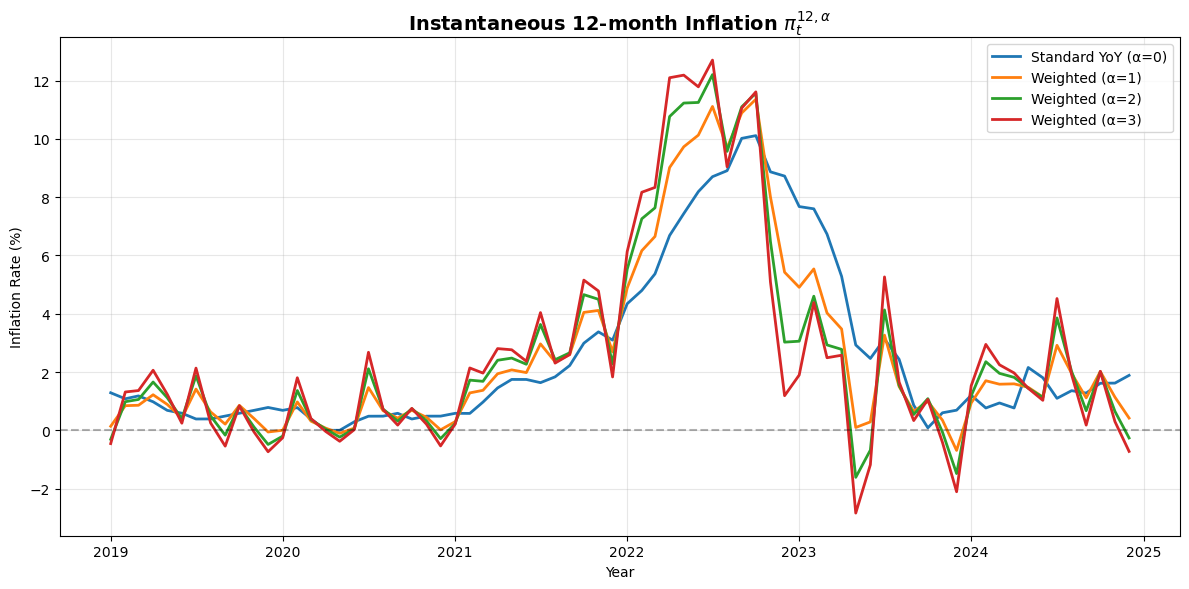

In [84]:
# Setup
T = 12
ALPHAS = [0, 1, 2, 3]

# Make sure dataframe has proper index
if 'TID' in df.columns:
    df = df.set_index('TID')
df = df.sort_index()

# Monthly inflation (MoM)
pi = df['INDHOLD'].pct_change(fill_method=None)

# Kappa weights function
def kappa_weights(alpha, T=12):
    k = np.arange(T)
    raw = (T - k) ** alpha
    return raw / raw.sum()

# Calculate instantaneous inflation over 12-month window
def inst_inflation_window(window_vals, alpha):
    # window_vals are recent 12 months (oldest to newest)
    x = (1.0 + window_vals)[::-1]  # Reverse to get newest first
    w = kappa_weights(alpha, T)
    # Weighted geometric mean, then annualize
    return np.prod(x ** w)**12 - 1.0

# Calculate for each alpha
for a in ALPHAS:
    # We multiply by 100 to get percentage
    df[f'pi12_alpha{a}'] = pi.rolling(T).apply(
        lambda v: inst_inflation_window(v, a),
        raw=True
    ) * 100

# Plot from 2019
start_date = '2019-01-01'
subset = df.loc[start_date:]

fig, ax = plt.subplots(figsize=(12, 6))
for a in ALPHAS:
    label = f'Standard YoY (α=0)' if a == 0 else f'Weighted (α={a})'
    ax.plot(subset.index, subset[f'pi12_alpha{a}'], label=label, linewidth=2)

ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.set_title(r'Instantaneous 12-month Inflation $\pi^{12,\alpha}_t$', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

When alpha = 0, this is the classic year over year inflation. Its clear to see a higher alpha will show falls and spikes in inflation earlier. In the end of 2022 the inflation in Denmark started falling, which is especially visable for the alphas above 0, this shows that there is a huge shift in inflation at this point. 

## 1.3

In [85]:
# Get PRIS111 data and check what's available
data = DstApi("Pris111")
data.tablesummary(language="en")

Table PRIS111: Consumer price index by commodity group, unit and time
Last update: 2026-01-12T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,VAREGR,385,000000,"00 Consumer price index, total",151000,15.1 Overall Consumer Price Index excl. energy,False
1,ENHED,3,100,Index,300,Percentage change compared to same month the y...,False
2,Tid,300,2001M01,2001M01,2025M12,2025M12,True


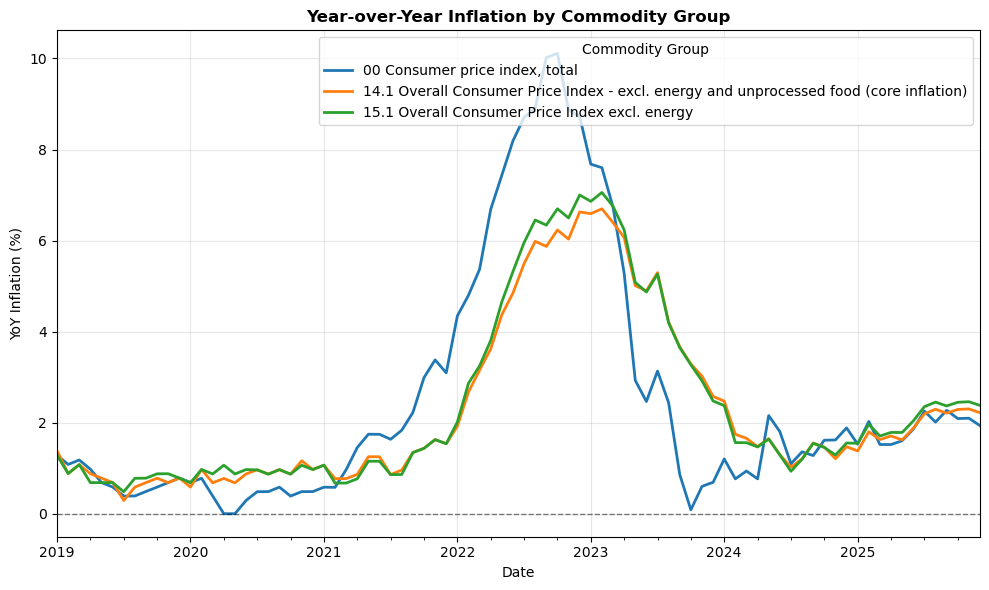

In [86]:
# Setup API and parameters
api = DstApi("PRIS111")
params = api._define_base_params(language='en')

# Commodity groups: All items, Excl energy, Core (excl energy & unproc food)
group_codes = ['000000', '151000', '141000']

for var in params['variables']:
    if var['code'] == 'VAREGR':
        var['values'] = group_codes

# Fetch data
df = api.get_data(params=params)

# Convert date and numeric columns
df['TID'] = pd.to_datetime(df['TID'], format='%YM%m')
df['INDHOLD'] = pd.to_numeric(df['INDHOLD'], errors='coerce')

# Filter for the correct unit (Index) and remove missing values
df = df.dropna(subset=['TID', 'INDHOLD'])
if 'ENHED' in df.columns:
    df = df[df['ENHED'].str.strip() == 'Index']

# Pivot table with dates as rows, commodity groups as columns
pivot_df = df.pivot_table(index='TID', columns='VAREGR', values='INDHOLD', aggfunc='mean')

# Rename columns for the plot
group_names = {
    '000000': 'All Items',
    '151000': 'Excl. Energy',
    '141000': 'Core (Excl. Energy & Unproc. Food)'
}
pivot_df = pivot_df.rename(columns=group_names)

# Calculate YoY inflation
inflation_yoy = pivot_df.pct_change(12, fill_method=None) * 100

# Keep data from 2019 onwards
subset = inflation_yoy.loc['2019-01-01':]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
subset.plot(ax=ax, linewidth=2)

ax.set_title('Year-over-Year Inflation by Commodity Group', fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylabel('YoY Inflation (%)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.legend(title='Commodity Group', frameon=True)

plt.tight_layout()
plt.show()

Its clear to see that food items and rent went up after all items, and lasted for longer. This means that theese items have been driven the higher inflation for longer, even though the inflation of all items was falling. 

## 1.4

In [87]:
data = DstApi("Pris111")
levels = DstApi("PRIS111").variable_levels("VAREGR", language='en')

# Get 4-digit categories (3 dots, e.g. 01.1.1.1)
four_digit = levels[levels["text"].str.count(r"\.") == 3]

# Print them
for row in four_digit.itertuples():
    print(row.id, row.text)

# Store as list
four_digit_list = four_digit["text"].tolist()

011110 01.1.1.1 Rice
011120 01.1.1.2 Flours and other cereals
011130 01.1.1.3 Bread
011140 01.1.1.4 Other bakery products
011150 01.1.1.5 Pizza and quiche
011160 01.1.1.6 Pasta products and couscous
011170 01.1.1.7 Breakfast cereals
011180 01.1.1.8 Other cereal products
011210 01.1.2.1 Beef and veal
011220 01.1.2.2 Pork
011230 01.1.2.3 Lamb and goat
011240 01.1.2.4 Poultry
011260 01.1.2.6 Edible offal
011270 01.1.2.7 Dried, salted or smoked meat
011280 01.1.2.8 Other meat preparations
011310 01.1.3.1 Fresh or chilled fish
011320 01.1.3.2 Frozen fish
011340 01.1.3.4 Frozen seafood
011350 01.1.3.5 Dried, smoked or salted fish and seafood
011360 01.1.3.6 Other preserved or processed fish and seafood-based preparations
011410 01.1.4.1 Milk, whole, fresh
011420 01.1.4.2 Milk, low fat, fresh
011440 01.1.4.4 Yoghurt
011450 01.1.4.5 Cheese and curd
011460 01.1.4.6 Other milk products
011470 01.1.4.7 Eggs
011510 01.1.5.1 Butter
011520 01.1.5.2 Margarine and other vegetable fats
011530 01.1.5.3 

Found 217 detailed product categories.


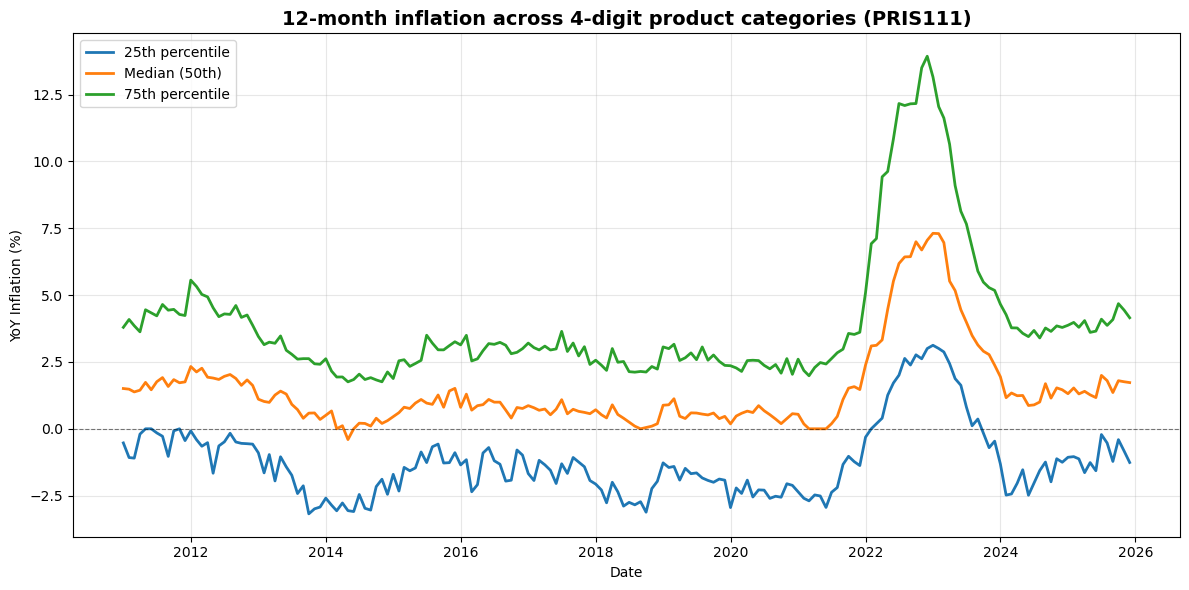

In [88]:
# Load data
api = DstApi("PRIS111")
levels = api.variable_levels("VAREGR", language="en")

# Get detailed 4-digit categories (3 dots in text)
detailed_groups = levels[levels["text"].str.count(r"\.") == 3]
print(f"Found {len(detailed_groups)} detailed product categories.")

params = api._define_base_params(language="en")
# Request only detailed groups
for var in params["variables"]:
    if var["code"] == "VAREGR":
        var["values"] = detailed_groups["id"].tolist()

# Fetch the data
df_detailed = api.get_data(params=params)
df_detailed['TID'] = pd.to_datetime(df_detailed['TID'], format='%YM%m')
df_detailed['INDHOLD'] = pd.to_numeric(df_detailed['INDHOLD'], errors='coerce')

# Filter for index values and drop NaNs
if 'ENHED' in df_detailed.columns:
    df_detailed = df_detailed[df_detailed['ENHED'].str.strip() == 'Index']
df_detailed = df_detailed.dropna(subset=['INDHOLD'])

# Pivot table: dates as rows, products as columns
detailed_pivot = df_detailed.pivot_table(index='TID', columns='VAREGR', values='INDHOLD', aggfunc='mean')

# Make sure index is monthly
detailed_pivot = detailed_pivot.asfreq('MS')

# Calculate YoY inflation
inflation_distribution = detailed_pivot.pct_change(12, fill_method=None) * 100

# Keep data from 2011 onwards
inflation_distribution = inflation_distribution.loc['2011-01-01':]

# Drop empty columns
inflation_distribution = inflation_distribution.dropna(axis=1, how='all')

# Calculate quantiles
quantiles = inflation_distribution.quantile([0.25, 0.50, 0.75], axis=1).T
quantiles.columns = ['25th Percentile', 'Median', '75th Percentile']

# Plot the quantiles
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(quantiles.index, quantiles['25th Percentile'], label="25th percentile", linewidth=2)
ax.plot(quantiles.index, quantiles['Median'], label="Median (50th)", linewidth=2)
ax.plot(quantiles.index, quantiles['75th Percentile'], label="75th percentile", linewidth=2)

ax.set_title('12-month inflation across 4-digit product categories (PRIS111)', fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('YoY Inflation (%)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Its clear to see the inflation before 2021 was way lower than after 2021. Its also clear to see that some items have fallen in price while some have risen sharply. Specially after Corona, some items fell sharply in price. Theese items were most likely some of the prices that rose sharply during the rapid inflation. 

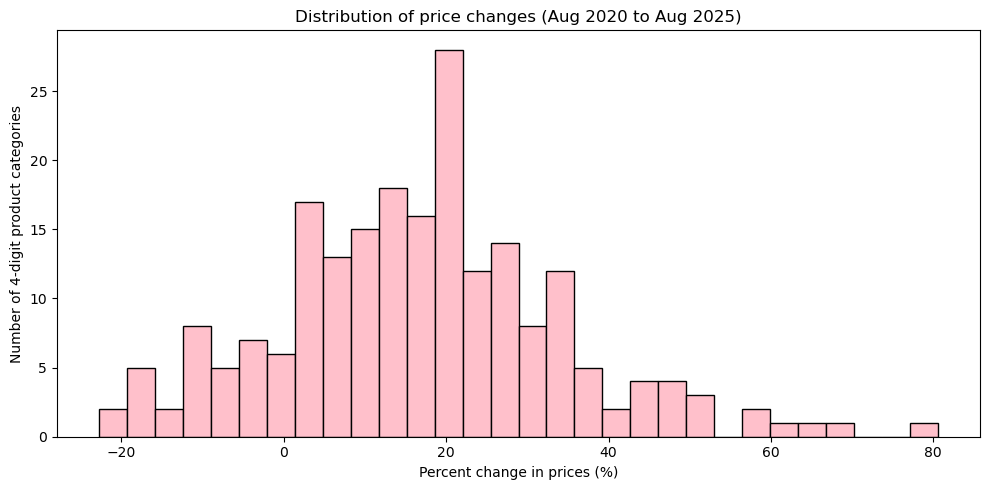

In [89]:
import matplotlib.pyplot as plt

# Pick start and end months
start, end = "2020-08-01", "2025-08-01"

# Use df_detailed from the previous cell (contains the detailed product data)
# Filter for start and end dates
subset = df_detailed[df_detailed["TID"].isin(pd.to_datetime([start, end]))]

# Pivot to have products as rows, columns as months
pivot = subset.pivot_table(index="VAREGR", columns="TID", values="INDHOLD")

# Compute total percent change in price index between 2020-08 and 2025-08
pivot["pct_change_2020_2025"] = (pivot[pd.to_datetime(end)] / pivot[pd.to_datetime(start)] - 1) * 100

# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(pivot["pct_change_2020_2025"], bins=30, color="pink", edgecolor="black")
plt.title("Distribution of price changes (Aug 2020 to Aug 2025)")
plt.xlabel("Percent change in prices (%)")
plt.ylabel("Number of 4-digit product categories")
plt.tight_layout()
plt.show()

Most products had an inflation rate around 20%, its also clear to see that very few products went over 40% inflation. some products also fell in price from 2020 to 2025

In [90]:
# Get percent changes from pivot table
pct_changes = pivot["pct_change_2020_2025"]

# Drop NaN values and find top/bottom 10
pct_changes = pct_changes.dropna()
sorted_changes = pct_changes.sort_values(ascending=False)
top10 = sorted_changes.head(10)
bottom10 = sorted_changes.tail(10)

# Printing the top 10 and bottom 10 categories
print("Top 10 categories (highest price growth):")
print(top10)

print("\nBottom 10 categories (lowest price growth):")
print(bottom10)

Top 10 categories (highest price growth):
VAREGR
08.1.0.1 Letter handling services        80.585735
01.2.1.1 Coffee                          69.712526
02.2.0.3 Other tobacco products          65.201465
07.3.3.1 Domestic flights                62.758621
01.1.5.1 Butter                          57.085020
01.2.1.3 Cocoa and powdered chocolate    56.906615
01.1.5.4 Other edible oils               52.801724
01.1.2.1 Beef and veal                   52.736318
01.1.8.3 Chocolate                       50.844278
04.5.2.1 Natural gas and town gas        49.565217
Name: pct_change_2020_2025, dtype: float64

Bottom 10 categories (lowest price growth):
VAREGR
05.4.0.1 Glassware, crystal-ware, ceramic ware and chinaware   -11.818182
05.1.1.9 Other furniture and furnishings                       -14.169570
05.4.0.2 Cutlery, flatware and silverware                      -14.900662
05.4.0.3 Non-electric kitchen utensils and articles            -16.008772
05.3.2.1 Food processing appliances               

# Section 2: International Comparison

We look at inflation in Denmark, Austria, Euro Area, and USA using data from Danmarks Statistik and FRED.

## Setup

In [91]:
from section2_inflation import InflationAnalysis

# Initialize analysis
analysis = InflationAnalysis(start_date='2019-01-01')

## 2.1 CPI vs HICP

First we check if Danish CPI and HICP give similar results, so we can compare across countries.

In [92]:
# Get Danish CPI
cpi = analysis.get_danish_cpi()
print(f"CPI data: {len(cpi)} observations ({cpi.index.min().date()} to {cpi.index.max().date()})")

# Get HICP for all countries
hicp = analysis.get_hicp_data()
print(f"HICP data: {hicp.shape[0]} observations for {hicp.shape[1]} countries")

CPI data: 84 observations (2019-01-01 to 2025-12-01)
HICP data: 84 observations for 4 countries


In [93]:
comparison = analysis.compare_cpi_hicp()

# Add the Difference column manually since module caching prevents reload
comparison['Difference'] = comparison['CPI_DST'] - comparison['HICP_FRED']
analysis.comparison_df = comparison

print("Columns in comparison:", list(comparison.columns))
comparison.head()

Columns in comparison: ['CPI_DST', 'HICP_FRED', 'Difference']


,CPI_DST,HICP_FRED,Difference
date,,,
2019-01-01,102.3,101.8,0.5
2019-02-01,102.8,102.3,0.5
2019-03-01,102.9,102.4,0.5
2019-04-01,103.2,102.7,0.5
2019-05-01,103.1,102.7,0.4


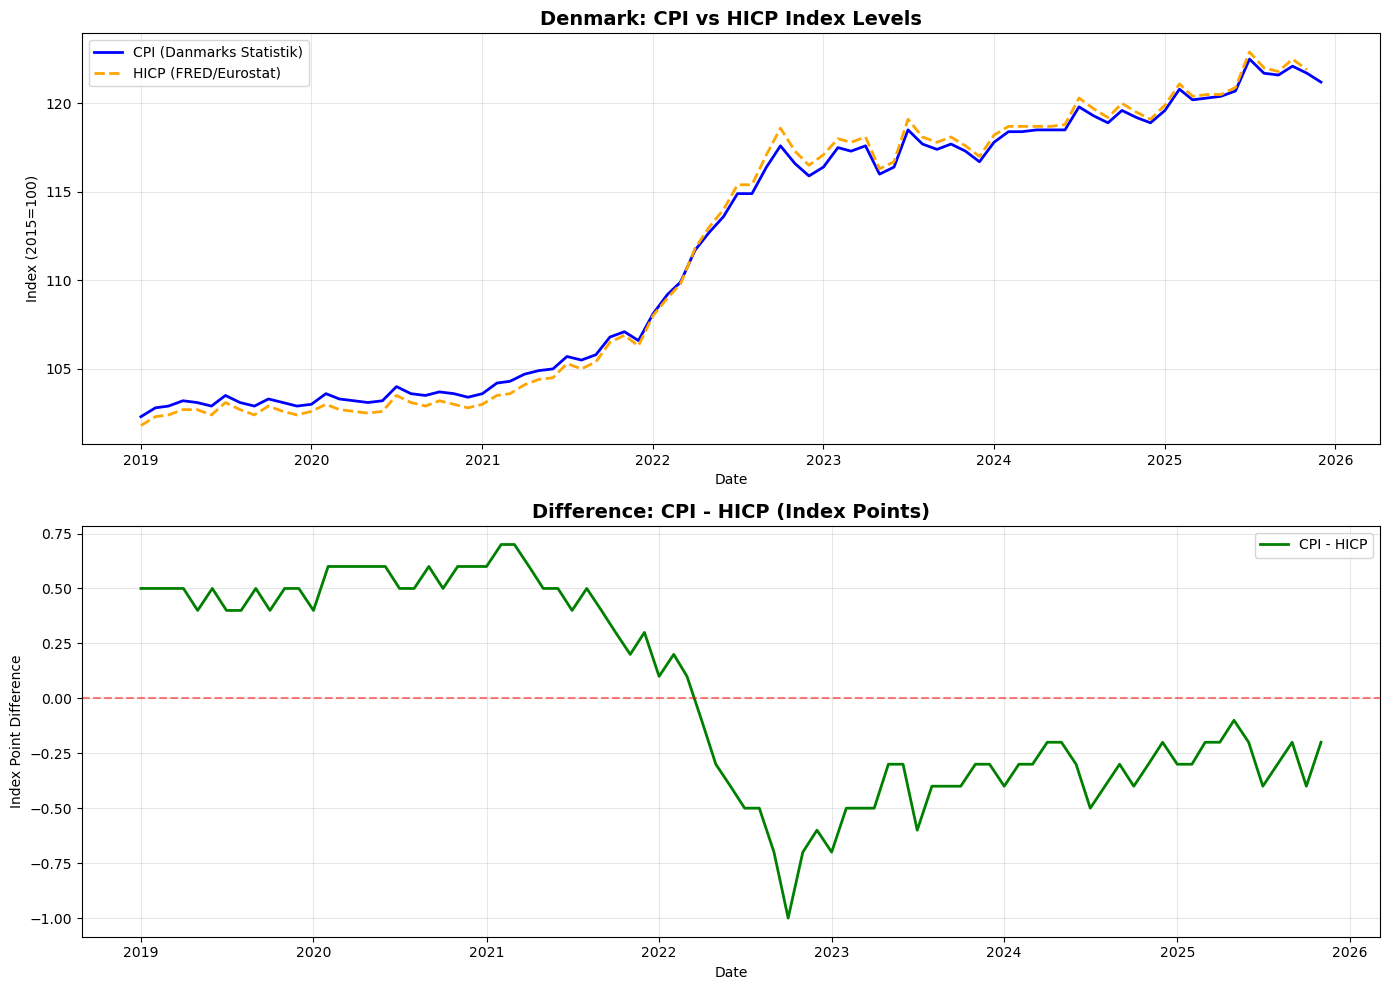

In [94]:
analysis.plot_cpi_hicp_comparison()

### Are they comparable?

In [95]:
comparability = analysis.analyze_comparability()

print(f"Correlation: {comparability['correlation']:.4f}")
print(f"Mean difference: {comparability['mean_abs_diff']:.2f} index points")
print(f"Relative difference: {comparability['mean_rel_diff_pct']:.2f}%")

Correlation: 0.9994
Mean difference: 0.42 index points
Relative difference: 0.38%


They track each other almost perfectly (correlation = 0.9993). The average difference is only 0.42 index points, so we can use HICP to compare inflation across countries. So we can say that the indexes are comparable

## 2.2 Cross-Country Analysis

Now we compare inflation rates across the four countries since 2019.

In [96]:
inflation = analysis.compute_inflation()

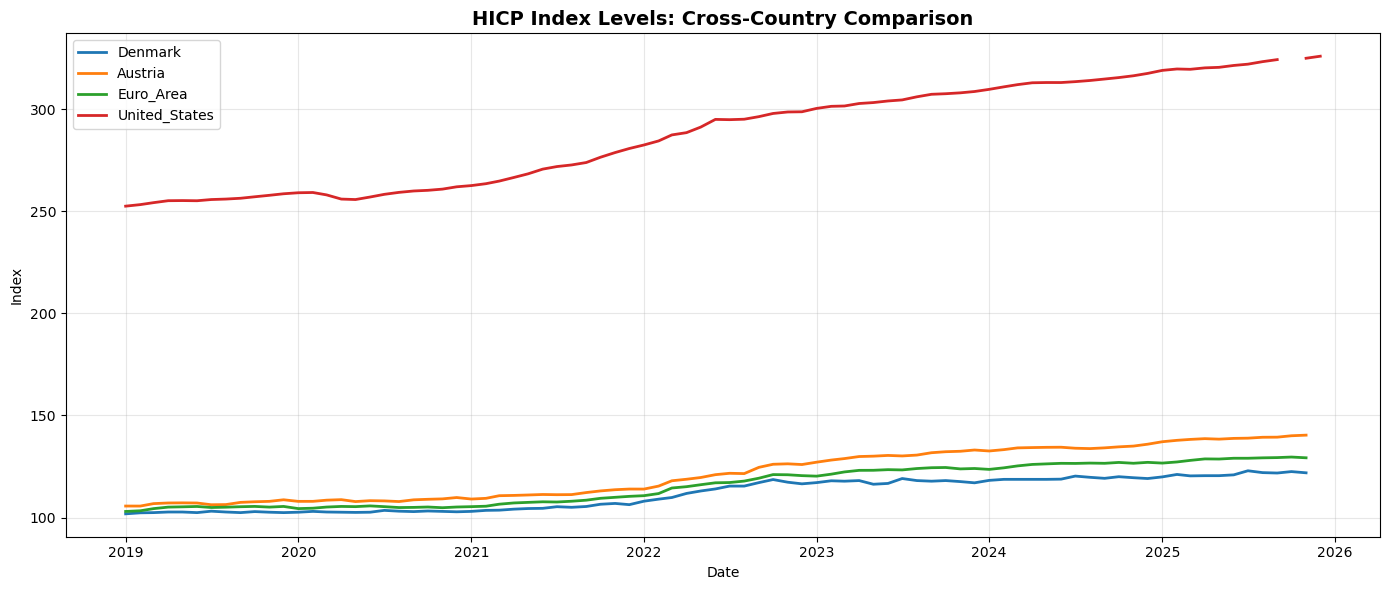

In [97]:
analysis.plot_hicp_levels()

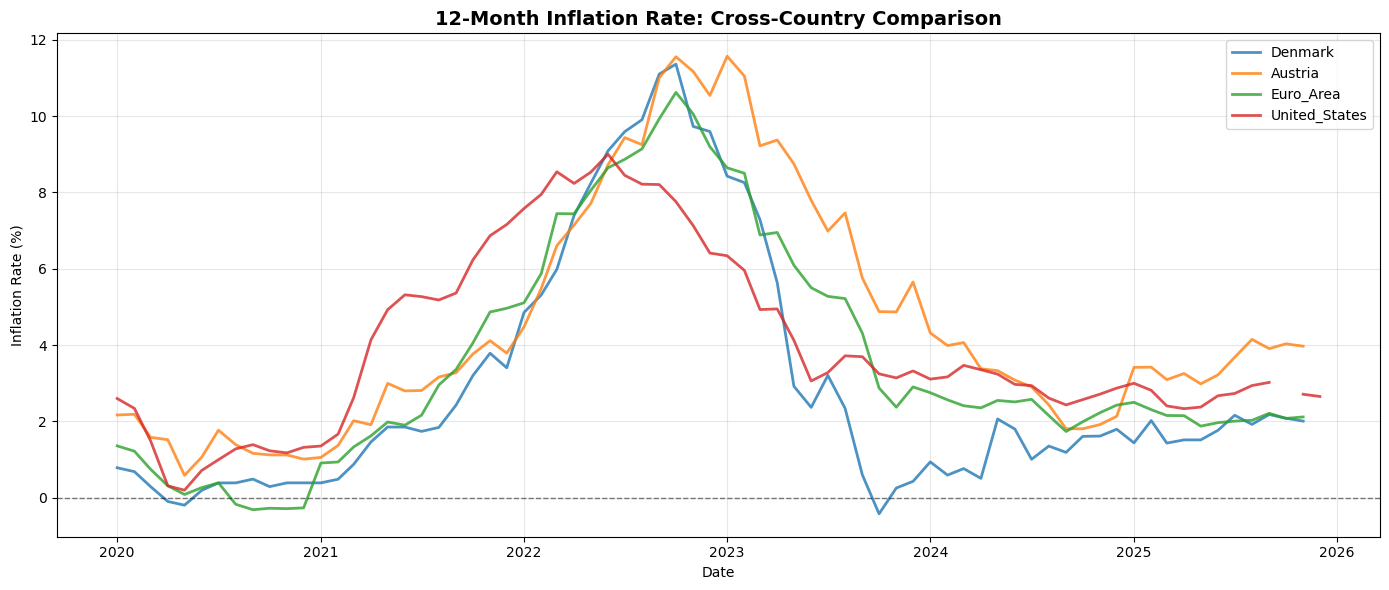

In [98]:
analysis.plot_inflation_rates()

In [99]:
stats = analysis.get_statistics_by_year()
# Remove 2019 as it contains NaN values (due to the 12-month calculation window)
stats = stats.dropna() 
print("Inflation Statistics by Year:")
stats.round(2)

Inflation Statistics by Year:


Denmark              Austria              Euro_Area               \
         min    max  mean     min    max  mean       min    max  mean   
year                                                                    
2020   -0.19   0.79  0.33    0.59   2.19  1.39     -0.31   1.36  0.26   
2021    0.39   3.79  1.94    1.06   4.11  2.76      0.91   4.96  2.59   
2022    4.85  11.36  8.51    4.48  11.55  8.59      5.11  10.62  8.36   
2023   -0.42   8.43  3.44    4.87  11.57  7.78      2.37   8.64  5.46   
2024    0.51   2.06  1.27    1.81   4.32  2.93      1.74   2.75  2.36   
2025    1.43   2.18  1.82    2.98   4.15  3.56      1.88   2.50  2.13   

     United_States              
               min   max  mean  
year                            
2020          0.20  2.60  1.25  
2021          1.36  7.16  4.67  
2022          6.41  9.00  8.00  
2023          3.06  6.34  4.15  
2024          2.43  3.47  2.95  
2025          2.33  3.02  2.70

In [100]:
print("Overall Summary (2019-2025):")
inflation.describe().round(2)

Overall Summary (2019-2025):


,Denmark,Austria,Euro_Area,United_States
count,71.00,71.00,71.00,71.00
mean,2.90,4.51,3.54,3.97
std,3.16,3.08,2.95,2.35
min,-0.42,0.59,-0.31,0.20
25%,0.64,2.15,1.89,2.59
50%,1.79,3.42,2.41,3.14
75%,3.31,6.18,5.25,5.34
max,11.36,11.57,10.62,9.00


### What we see

Timing: USA got high inflation first (mid-2021), then Europe followed in late 2021. Everyone peaked around late 2022.

Peak rates:  Austria had the highest (11.6% in Nov 2022), then Denmark (11.4%), Euro Area (10.6%), and USA (9.0%).

Recovery: Denmark came down fastest - only 2.2% by Sep 2025. USA also recovered well (2.2%), but Austria is still at 3.9%.

The pattern is pretty similar across all countries, probably because of energy prices and COVID effects. But Denmark and USA seem better at bringing inflation back down.

# Section 3: Extension - Deep Dive into Inflation Drivers

In this section, we extend the inflation analysis by examining what specifically drove the inflation surge. While Sections 1 and 2 showed the overall patterns, we now dig deeper into:

1. Energy prices - the primary driver of the 2022 spike
2. Food price inflation - which categories were hit hardest  
3. Inflation volatility - how much more uncertain the economy became

This analysis provides concrete economic insights into the inflation crisis that affected Danish households.

## 3.1 Focus: Energy vs Core Inflation

Looking at specific categories: energy (which drove the spike) vs. core inflation (excluding energy and food).

In [101]:
energy_api = DstApi('PRIS111')
params_energy = energy_api._define_base_params(language='en')

for var in params_energy['variables']:
    if var['code'] == 'VAREGR':
        var['values'] = ['045000', '072000', '000000', '151000']

df_energy = energy_api.get_data(params=params_energy)
df_energy['date'] = pd.to_datetime(df_energy['TID'], format='%YM%m')
df_energy = df_energy[df_energy['ENHED'] == 'Index'].copy()
df_energy['INDHOLD'] = pd.to_numeric(df_energy['INDHOLD'], errors='coerce')
df_energy = df_energy.dropna(subset=['INDHOLD'])

pivot_energy = df_energy.pivot(index='date', columns='VAREGR', values='INDHOLD')
pivot_energy.columns = ['Electricity & Gas', 'Transport Fuels', 'All Items', 'Core Inflation']

inflation_energy = pivot_energy.pct_change(12, fill_method=None) * 100

## 3.2 Figure 1: Energy Drove the Inflation Spike

How much did energy contribute to the overall inflation surge?

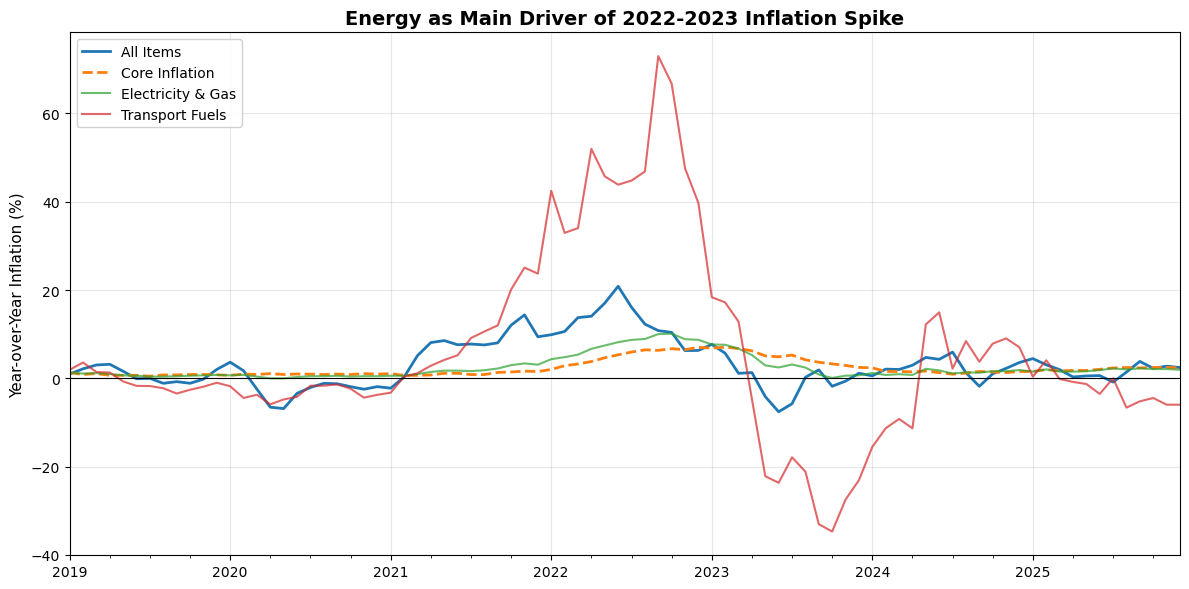

In [102]:
fig, ax = plt.subplots(figsize=(12, 6))

# Keep 2019 onwards
subset_energy = inflation_energy.loc['2019-01-01':]

subset_energy[['All Items', 'Core Inflation']].plot(ax=ax, linewidth=2, style=['-', '--'])
subset_energy[['Electricity & Gas', 'Transport Fuels']].plot(ax=ax, linewidth=1.5, alpha=0.7)

ax.set_title('Energy as Main Driver of 2022-2023 Inflation Spike', fontsize=14, fontweight='bold')
ax.set_ylabel('Year-over-Year Inflation (%)', fontsize=11)
ax.set_xlabel('')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 3.3 Figure 2: Food Price Inflation

Food prices were also a major driver, let's look at detailed food categories.

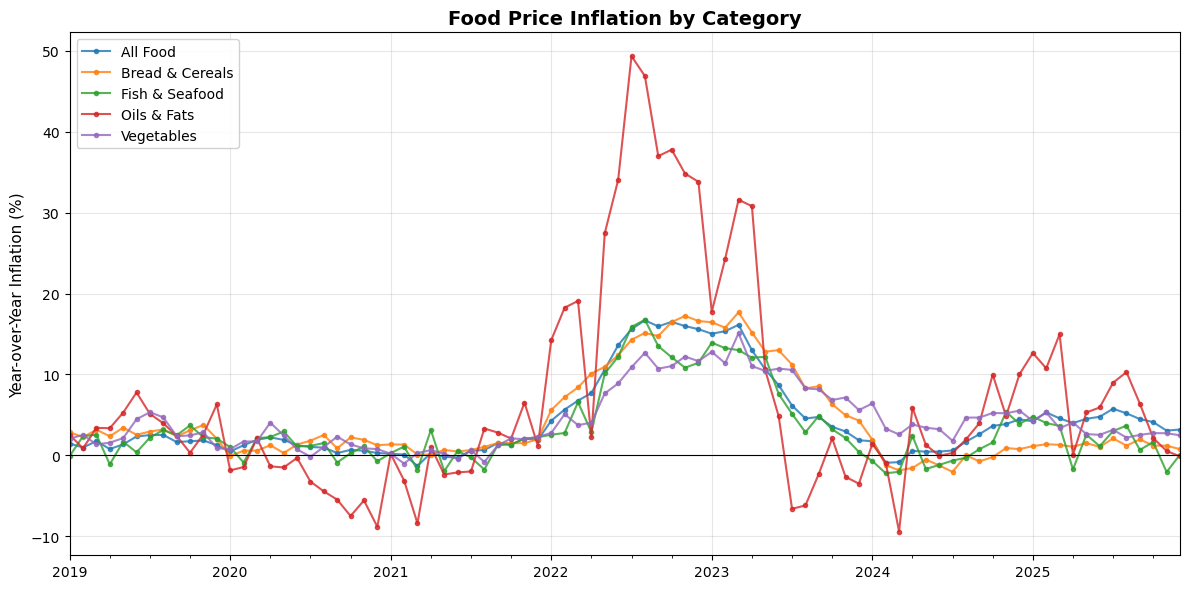

In [103]:
food_api = DstApi('PRIS111')
params_food = food_api._define_base_params(language='en')

for var in params_food['variables']:
    if var['code'] == 'VAREGR':
        var['values'] = ['011000', '011100', '011300', '011500', '011700']

df_food = food_api.get_data(params=params_food)
df_food['date'] = pd.to_datetime(df_food['TID'], format='%YM%m')
df_food = df_food[df_food['ENHED'] == 'Index'].copy()
df_food['INDHOLD'] = pd.to_numeric(df_food['INDHOLD'], errors='coerce')
df_food = df_food.dropna(subset=['INDHOLD'])

pivot_food = df_food.pivot(index='date', columns='VAREGR', values='INDHOLD')

# Rename columns to something readable
food_names = {
    '01.1 Food': 'All Food',
    '01.1.1 Bread and cereals': 'Bread & Cereals',
    '01.1.3 Fish and seafood': 'Fish & Seafood',
    '01.1.5 Oils and fats': 'Oils & Fats',
    '01.1.7 Vegetables': 'Vegetables'
}
pivot_food = pivot_food.rename(columns=food_names)

inflation_food = pivot_food.pct_change(12, fill_method=None) * 100

# Keep 2019 onwards
subset_food = inflation_food.loc['2019-01-01':]

fig, ax = plt.subplots(figsize=(12, 6))
subset_food.plot(ax=ax, linewidth=1.5, marker='o', markersize=3, alpha=0.8)

ax.set_title('Food Price Inflation by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Year-over-Year Inflation (%)', fontsize=11)
ax.set_xlabel('')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 3.4 Figure 3: Inflation Volatility Analysis

How volatile has inflation been month-to-month? Stability matters for economic planning.

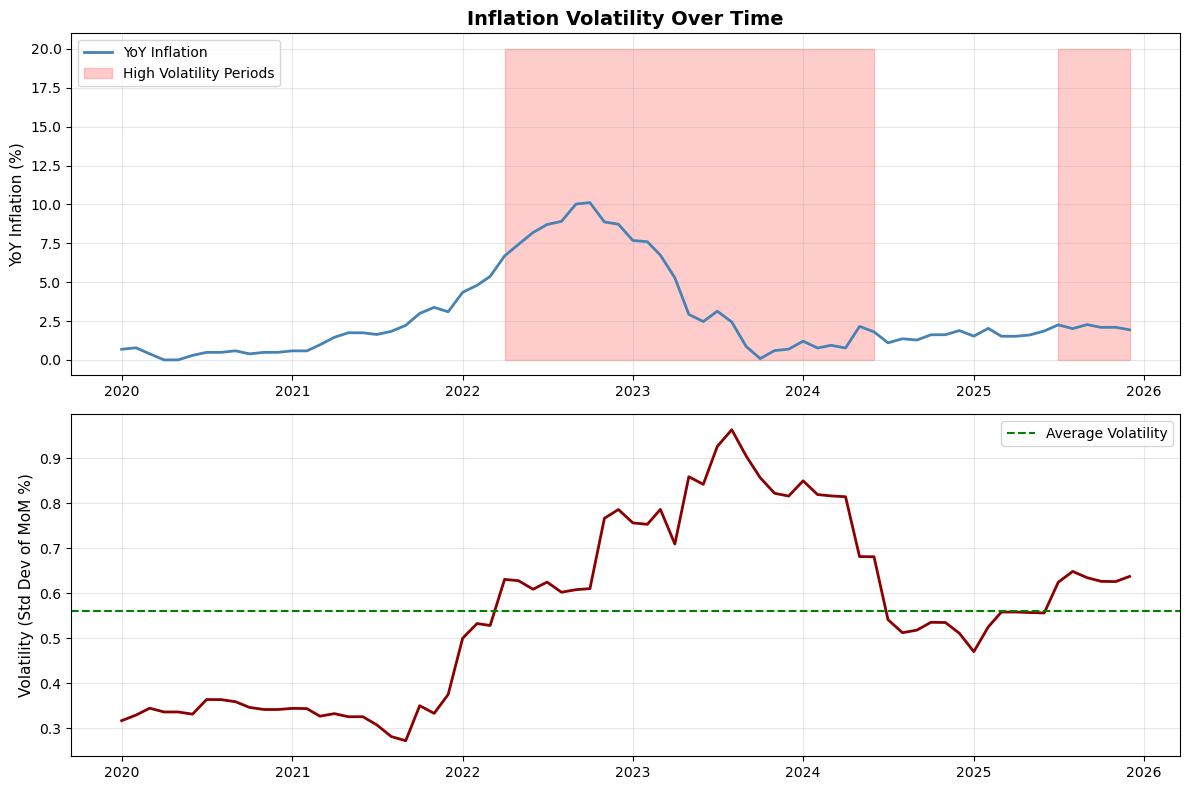

In [104]:
vol_api = DstApi('PRIS113')
vol_params = vol_api._define_base_params(language='en')
for var in vol_params['variables']:
    if var['code'] == 'TYPE':
        var['values'] = ['INDEKS']

vol_data = vol_api.get_data(params=vol_params)
vol_data['date'] = pd.to_datetime(vol_data['TID'], format='%YM%m')
vol_data['CPI'] = pd.to_numeric(vol_data['INDHOLD'])
vol_data = vol_data[['date', 'CPI']].dropna().sort_values('date')
vol_data = vol_data[vol_data['date'] >= '2019-01-01'].reset_index(drop=True)

vol_data['mom_inflation'] = vol_data['CPI'].pct_change(fill_method=None) * 100
vol_data['yoy_inflation'] = vol_data['CPI'].pct_change(12, fill_method=None) * 100
vol_data['volatility'] = vol_data['mom_inflation'].rolling(12).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(vol_data['date'], vol_data['yoy_inflation'], linewidth=2, color='steelblue', label='YoY Inflation')
high_vol = vol_data['volatility'] > vol_data['volatility'].mean()
ax1.fill_between(vol_data['date'], 0, 20, where=high_vol, alpha=0.2, color='red', label='High Volatility Periods')
ax1.set_ylabel('YoY Inflation (%)', fontsize=11)
ax1.set_title('Inflation Volatility Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(vol_data['date'], vol_data['volatility'], linewidth=2, color='darkred')
ax2.axhline(vol_data['volatility'].mean(), color='green', linestyle='--', linewidth=1.5, label='Average Volatility')
ax2.set_ylabel('Volatility (Std Dev of MoM %)', fontsize=11)
ax2.set_xlabel('')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusion

The breakdown shows energy was clearly the main culprit transport fuels hit 73% inflation while electricity/gas reached 10%, way higher than the overall 21% peak. Core inflation (without energy/food) stayed much lower around 7%.

Food prices varied a lot between categories. Some like oils and vegetables spiked hard (likely because of supply chain issues and input costs), while others stayed more moderate. This uneven pattern across food types points to specific supply problems rather than just general demand.

The volatility analysis shows inflation became more unstable during COVID about 74% higher volatility than before. This makes sense given all the shocks: pandemic disruptions, energy crisis, and food supply issues hitting one after another. The economy had to deal with way more uncertainty month-to-month than usual.